<a href="https://colab.research.google.com/github/Datdeptrai912005/DemoGit/blob/main/MLLMS_Traine_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!pip install "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
!pip install --no-deps "xformers<0.0.27" "trl<0.9.0" peft accelerate bitsandbytes datasets

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
  Cloning https://github.com/unslothai/unsloth.git to /tmp/pip-install-guef5vvz/unsloth_da841cbf5c7949fba6880452ab084281
  Running command git clone --filter=blob:none --quiet https://github.com/unslothai/unsloth.git /tmp/pip-install-guef5vvz/unsloth_da841cbf5c7949fba6880452ab084281
  Resolved https://github.com/unslothai/unsloth.git to commit 6764cb9b90c7d9e2e0e170ce70f841d0bcf3d4ea
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached xformers-0.0.26.post1.tar.gz (4.1 MB)
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 245.2/245.2 kB 10.2 MB/s eta 0:00:00
  error: subprocess-exited-with-error
  
  × python setup.py bdist_wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originat

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!pip install transformers datasets evaluate accelerate scikit-learn

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.1 MB/s eta 0:00:00


In [ ]:
from unsloth import FastLanguageModel
import torch
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/Qwen2.5-1.5B-Instruct",
    max_seq_length = 2048,
    dtype = None,
    load_in_4bit = True,
)
model = FastLanguageModel.get_peft_model(
    model,
    r = 16,
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj",],
    lora_alpha = 16,
    lora_dropout = 0,
    bias = "none",
    use_gradient_checkpointing = "unsloth",
    random_state = 3407,
)
print("✅ Tải mô hình thành công ")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.4.5: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/1.53G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/270 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

added_tokens.json:   0%|          | 0.00/605 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

unsloth/qwen2.5-1.5b-instruct-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Unsloth 2026.4.5 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.


✅ Tải mô hình thành công 


In [ ]:
from datasets import load_dataset
from unsloth.chat_templates import get_chat_template
tokenizer = get_chat_template(
    tokenizer,
    chat_template = "chatml",
)

def formatting_prompts_func(examples):
    convos = examples["messages"]
    texts = [tokenizer.apply_chat_template(convo, tokenize=False, add_generation_prompt=False) for convo in convos]
    return { "text" : texts }

train_dataset = load_dataset("json", data_files="/content/drive/MyDrive/train_data.jsonl", split="train")
test_dataset = load_dataset("json", data_files="/content/drive/MyDrive/test_data.jsonl", split="train")
train_dataset = train_dataset.map(formatting_prompts_func, batched=True)
test_dataset = test_dataset.map(formatting_prompts_func, batched=True)

print(f"📚 Đã nạp {len(train_dataset)} mẫu để Dạy (Train)")
print(f"📝 Đã nạp {len(test_dataset)} mẫu để Kiểm tra (Test)")

Unsloth: Will map <|im_end|> to EOS = <|im_end|>.


Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

Map:   0%|          | 0/5924 [00:00<?, ? examples/s]

Map:   0%|          | 0/659 [00:00<?, ? examples/s]

📚 Đã nạp 5924 mẫu để Dạy (Train)
📝 Đã nạp 659 mẫu để Kiểm tra (Test)


In [ ]:
from trl import SFTTrainer
from transformers import TrainingArguments
from unsloth import is_bfloat16_supported

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = train_dataset,
    eval_dataset = test_dataset,
    dataset_text_field = "text",
    max_seq_length = 2048,
    dataset_num_proc = 2,
    packing = False,
    args = TrainingArguments(
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 4,
        warmup_steps = 10,
        num_train_epochs = 1,
        learning_rate = 2e-4,
        fp16 = not is_bfloat16_supported(),
        bf16 = is_bfloat16_supported(),
        logging_steps = 20,
        eval_strategy = "steps",
        eval_steps = 100,
        optim = "adamw_8bit",
        weight_decay = 0.01,
        lr_scheduler_type = "linear",
        seed = 3407,
        output_dir = "outputs",
    ),
)
trainer_stats = trainer.train()

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/5924 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/659 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 5,924 | Num Epochs = 1 | Total steps = 741
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 18,464,768 of 1,562,179,072 (1.18% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Step,Training Loss,Validation Loss
100,1.714398,1.597926
200,1.845243,1.565735
300,1.790656,1.553989
400,1.608353,1.543481
500,1.661284,1.534514
600,1.905134,1.529428
700,1.590807,1.525120
741,1.801177,1.524636


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:172: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API 

In [ ]:

save_path = "/content/drive/MyDrive/MLLA /Qwen_FakeNews_Model"
model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)
print(f"✅ Đã lưu thành công trí tuệ của mô hình tại: {save_path}")

✅ Đã lưu thành công trí tuệ của mô hình tại: /content/drive/MyDrive/MLLA /Qwen_FakeNews_Model


In [ ]:
import torch
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_name = "bert-base-multilingual-cased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)
def preprocess_function(examples):
    texts = []
    labels = []
    for conv in examples["messages"]:
        user_text = next((msg["content"] for msg in conv if msg["role"] == "user"), "")
        label_text = next((msg["content"] for msg in conv if msg["role"] == "assistant"), "0")

        texts.append(user_text)
        labels.append(int(label_text))

    result = tokenizer(texts, padding="max_length", truncation=True, max_length=512)
    result["labels"] = labels
    return result

print("Đang tải dữ liệu từ Drive...")
train_dataset = load_dataset("json", data_files="/content/drive/MyDrive/train_data.jsonl", split="train")
test_dataset = load_dataset("json", data_files="/content/drive/MyDrive/test_data.jsonl", split="train")

tokenized_train = train_dataset.map(preprocess_function, batched=True, remove_columns=["messages"])
tokenized_test = test_dataset.map(preprocess_function, batched=True, remove_columns=["messages"])

print(f"✅ Đã nạp {len(tokenized_train)} mẫu Train và {len(tokenized_test)} mẫu Test cho mBERT.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

Map:   0%|          | 0/5924 [00:00<?, ? examples/s]

Map:   0%|          | 0/659 [00:00<?, ? examples/s]

✅ Đã nạp 5924 mẫu Train và 659 mẫu Test cho mBERT.


In [ ]:
from transformers import TrainingArguments, Trainer
import evaluate
import numpy as np

# 1. Định nghĩa cách chấm điểm (Accuracy và F1-Score)
metric_acc = evaluate.load("accuracy")
metric_f1 = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = metric_acc.compute(predictions=predictions, references=labels)["accuracy"]
    f1 = metric_f1.compute(predictions=predictions, references=labels)["f1"]
    return {"accuracy": acc, "f1": f1}

# 2. Cấu hình thông số học tập
training_args = TrainingArguments(
    output_dir="./mbert_results",
    learning_rate=2e-5,
    per_device_train_batch_size=16, # mBERT nhẹ nên có thể nhồi 16 câu cùng lúc
    per_device_eval_batch_size=16,
    num_train_epochs=3, # mBERT thường cần học 3 vòng mới ngấm
    weight_decay=0.01,
    eval_strategy="epoch", # Chấm điểm sau mỗi vòng học
    save_strategy="epoch",
    load_best_model_at_end=True,
    fp16=True, # Tăng tốc độ train trên GPU T4
)

# 3. Tạo "Giáo viên" huấn luyện
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    processing_class=tokenizer, # <-- TÔI ĐÃ SỬA DÒNG NÀY CHO BẠN
    compute_metrics=compute_metrics,
)
# 4. BẮT ĐẦU HỌC!
print("Bắt đầu huấn luyện mBERT...")
trainer.train()

# 5. LÀM BÀI THI CUỐI KỲ VÀ IN KẾT QUẢ
print("\n" + "="*40)
print("🏆 KẾT QUẢ CUỐI CÙNG CỦA mBERT TRÊN TẬP TEST 🏆")
print("="*40)
final_results = trainer.evaluate(tokenized_test)
print(f"Độ chính xác (Accuracy): {final_results['eval_accuracy'] * 100:.2f}%")
print(f"Điểm F1-Score:           {final_results['eval_f1'] * 100:.2f}%")
print("="*40)

# (Tùy chọn) Lưu mô hình
trainer.save_model("/content/drive/MyDrive/mBERT_FakeNews_Model")
print("Đã lưu mô hình mBERT lên Drive.")

Bắt đầu huấn luyện mBERT...


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,0.468567,0.767830,0.670968
2,0.465659,0.506671,0.763278,0.611940
3,0.362001,0.552842,0.752656,0.524781


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


🏆 KẾT QUẢ CUỐI CÙNG CỦA mBERT TRÊN TẬP TEST 🏆


Độ chính xác (Accuracy): 76.78%
Điểm F1-Score:           67.10%


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Đã lưu mô hình mBERT lên Drive.


Đang thu thập đáp án của mBERT...


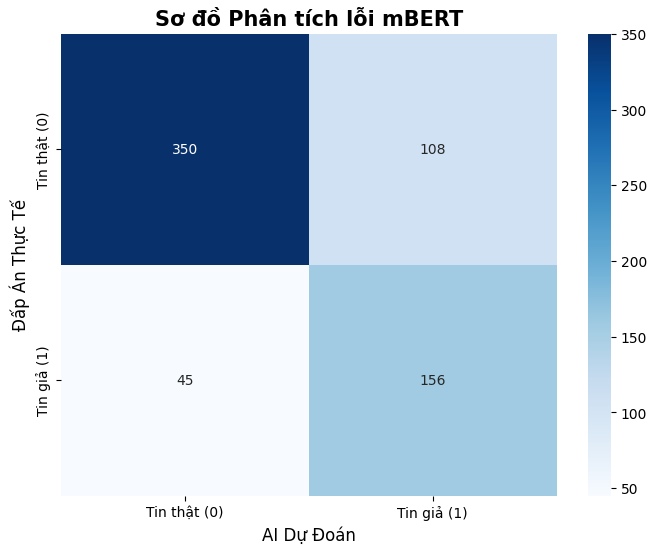

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

print("Đang thu thập đáp án của mBERT...")
predictions = trainer.predict(tokenized_test)
y_pred = np.argmax(predictions.predictions, axis=-1)
y_true = predictions.label_ids

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Tin thật (0)', 'Tin giả (1)'],
            yticklabels=['Tin thật (0)', 'Tin giả (1)'])

plt.title('Sơ đồ Phân tích lỗi mBERT', fontsize=15, fontweight='bold')
plt.xlabel('AI Dự Đoán', fontsize=12)
plt.ylabel('Đấp Án Thực Tế', fontsize=12)
plt.show()

Đang tải lại mô hình Qwen từ Drive...
==((====))==  Unsloth 2026.4.5: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

unsloth/qwen2.5-1.5b-instruct-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Unsloth 2026.4.5 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.


Generating train split: 0 examples [00:00, ? examples/s]

Đang yêu cầu Qwen làm toàn bộ đề thi Test (Sẽ mất vài phút)...


  0%|          | 0/659 [00:00<?, ?it/s]The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Both `max_new_tokens` (=10) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask 

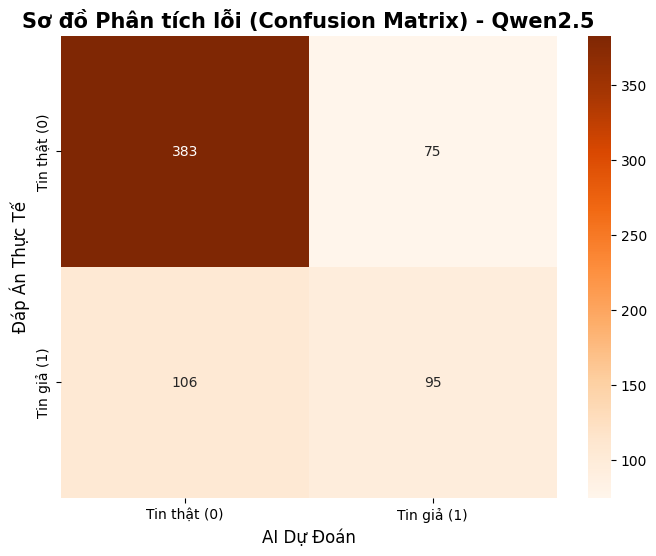

In [ ]:

from unsloth import FastLanguageModel
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from tqdm import tqdm
import json

print("Đang tải lại mô hình Qwen từ Drive...")
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "/content/drive/MyDrive/MLLA /Qwen_FakeNews_Model",
    max_seq_length = 2048,
    dtype = None,
    load_in_4bit = True,
)
FastLanguageModel.for_inference(model)

test_dataset = load_dataset("json", data_files="/content/drive/MyDrive/test_data.jsonl", split="train")

y_true = []
y_pred = []

print("Đang yêu cầu Qwen làm toàn bộ đề thi Test (Sẽ mất vài phút)...")
for item in tqdm(test_dataset):
    # Lấy đáp án thật
    true_label = next(msg["content"] for msg in item["messages"] if msg["role"] == "assistant")
    y_true.append(int(true_label))

    # Cho Qwen đọc và đoán
    user_text = next(msg["content"] for msg in item["messages"] if msg["role"] == "user")
    messages = [
        {"role": "system", "content": "Phân tích tin giả."},
        {"role": "user", "content": user_text}
    ]

    inputs = tokenizer.apply_chat_template(messages, tokenize=True, add_generation_prompt=True, return_tensors="pt").to("cuda")
    outputs = model.generate(input_ids=inputs, max_new_tokens=10, use_cache=True, pad_token_id=tokenizer.eos_token_id)
    response = tokenizer.batch_decode(outputs)[0]

    pred_str = response.split("<|im_start|>assistant\n")[-1].replace("<|im_end|>", "").strip()

    if "1" in pred_str:
        y_pred.append(1)
    else:
        y_pred.append(0)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Tin thật (0)', 'Tin giả (1)'],
            yticklabels=['Tin thật (0)', 'Tin giả (1)'])

plt.title('Sơ đồ Phân tích lỗi (Confusion Matrix) - Qwen2.5', fontsize=15, fontweight='bold')
plt.xlabel('AI Dự Đoán', fontsize=12)
plt.ylabel('Đáp Án Thực Tế', fontsize=12)
plt.show()